In [65]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import keras, datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.model.assemble_model import build_reg_model
from src.model.miscellaneous import create_seq_dataset_multiple_input_single_output
from sklearn.metrics import r2_score

In [2]:
file_name_list = os.listdir('data')

data_list = []

for i, file_name in enumerate(file_name_list):
    data = pd.read_csv('data/' + file_name)
    data['index'] = i
    data_list.append(data)

data = pd.concat(data_list)
data.reset_index(drop=True, inplace=True)

In [3]:
data = data[data['Status'] == 'TEST']
data.reset_index(drop=True, inplace=True)

In [4]:
data

,Time(s),Pressure(bar),Leak(cm3/min),Status,index
0,58.0,1.0,5.330,TEST,0
1,58.1,1.0,5.276,TEST,0
2,58.2,1.0,5.223,TEST,0
3,58.3,1.0,5.170,TEST,0
4,58.4,1.0,5.118,TEST,0
...,...,...,...,...,...
1311,89.6,1.0,-2.714,TEST,3
1312,89.7,1.0,-2.768,TEST,3
1313,89.8,1.0,-2.822,TEST,3
1314,89.9,1.0,-2.876,TEST,3


In [5]:
flow_rate_df = data['Leak(cm3/min)']
flow_rate_arr = flow_rate_df.to_numpy()
flow_rate_arr = flow_rate_arr.reshape(-1, 1)
flow_rate_arr = np.concatenate([flow_rate_arr, flow_rate_arr], axis=1)

Text(0, 0.5, 'Flow-Rate(cm3/min)')

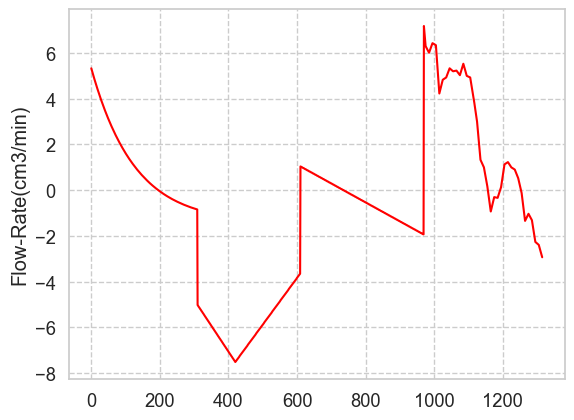

In [6]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_rate_df, color='red')

plt.ylabel('Flow-Rate(cm3/min)')

Text(0.5, 0, 'Flow-Rate(cm3/min)')

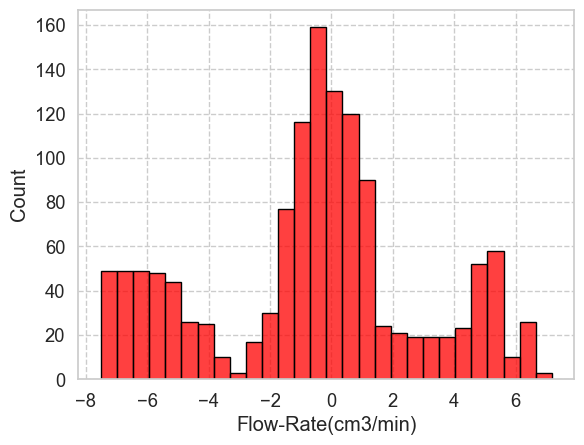

In [7]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.histplot(flow_rate_df, color='red', edgecolor='black')

plt.xlabel('Flow-Rate(cm3/min)')

In [50]:
seq_len = 30
pred_distance = 100

train_feature, train_target = create_seq_dataset_multiple_input_single_output(data=flow_rate_arr, seq_len=seq_len, pred_distance=pred_distance, target_idx_pos=1)

print(train_feature.shape, train_target.shape)

creating sequence dataset...:   0%|          | 0/1216 [00:00<?, ?it/s]

(1187, 30, 1) (1187, 1)


In [51]:
model = build_reg_model(input_shape=(train_feature.shape[1:]), d_dims=64, dropout_rate=0.5, learning_rate=0.001)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 30, 64)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dense_37[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 30, 64)    │          0 │ conv1d_6[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ conv1d_7[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_37[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 30, 64)    │          0 │ add_21[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 30, 64)    │     12,352 │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 30, 64)    │          0 │ conv1d_8[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ conv1d_9[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 30, 64)    │          0 │ add_22[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 30, 64)    │     12,352 │ activation_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 30, 64)    │          0 │ conv1d_10[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 30, 64)    │     12,352 │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ conv1d_11[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ activation_20[0]

 Total params: 380,914 (1.45 MB)

 Trainable params: 380,914 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=500, verbose=0)
csv_logger = keras.callbacks.CSVLogger(filename=f'log_{pred_distance}_model.csv', append=False, separator=',')
model_chk_point = keras.callbacks.ModelCheckpoint(filepath=f'model_{pred_distance}.keras', monitor="val_loss", verbose=2,
                                                  save_best_only=True, save_weights_only=False, mode="min", save_freq="epoch", initial_value_threshold=None)

log_dir = "logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)


model.fit(x=train_feature, y=train_target, validation_data=(train_feature, train_target),
          epochs=999999, batch_size=200, verbose=0, callbacks=[early_stop, csv_logger, model_chk_point])


Epoch 1: val_loss improved from None to 2.18730, saving model to model_100.keras

Epoch 1: finished saving model to model_100.keras

Epoch 2: val_loss improved from 2.18730 to 1.47448, saving model to model_100.keras

Epoch 2: finished saving model to model_100.keras

Epoch 3: val_loss improved from 1.47448 to 1.33260, saving model to model_100.keras

Epoch 3: finished saving model to model_100.keras

Epoch 4: val_loss did not improve from 1.33260

Epoch 5: val_loss did not improve from 1.33260

Epoch 6: val_loss did not improve from 1.33260

Epoch 7: val_loss did not improve from 1.33260

Epoch 8: val_loss did not improve from 1.33260

Epoch 9: val_loss did not improve from 1.33260

Epoch 10: val_loss improved from 1.33260 to 1.21018, saving model to model_100.keras

Epoch 10: finished saving model to model_100.keras

Epoch 11: val_loss did not improve from 1.21018

Epoch 12: val_loss did not improve from 1.21018

Epoch 13: val_loss did not improve from 1.21018

Epoch 14: val_loss di

In [62]:
result = pd.read_csv('log_100_model.csv')
result

,epoch,loss,mean_absolute_error,mean_absolute_percentage_error,val_loss,val_mean_absolute_error,val_mean_absolute_percentage_error
0,0,3.27000,3.89461,3435727.00000,2.18730,2.82940,1295542.62500
1,1,2.50392,3.11475,5428690.50000,1.47448,1.97135,1381661.12500
2,2,2.10294,2.68610,1022099.18750,1.33260,1.85124,1900623.62500
3,3,2.01444,2.59738,887172.87500,1.39886,1.92128,665362.37500
4,4,1.91538,2.49614,747584.18750,1.63528,2.17378,1036268.68750
...,...,...,...,...,...,...,...
3730,3730,0.13207,0.28393,25320.32812,0.08176,0.19395,43111.85938
3731,3731,0.11489,0.26830,50336.48828,0.06630,0.16355,29792.30664
3732,3732,0.10956,0.25686,73648.60938,0.06545,0.17147,44568.82031
3733,3733,0.09543,0.23844,84375.12500,0.08018,0.18336,58350.22656


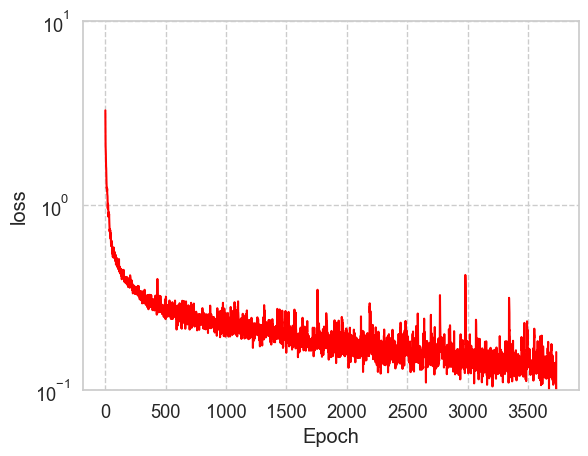

In [63]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(result['loss'], color='red')


plt.xlabel('Epoch')

plt.ylim(0.1, 10)
plt.yscale('log')


In [55]:
model = keras.models.load_model(f'model_{pred_distance}.keras')

In [56]:
train_pred = np.squeeze(model.predict(train_feature))

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step


Text(0, 0.5, 'Predicted Flow-Rate(cm3/min)')

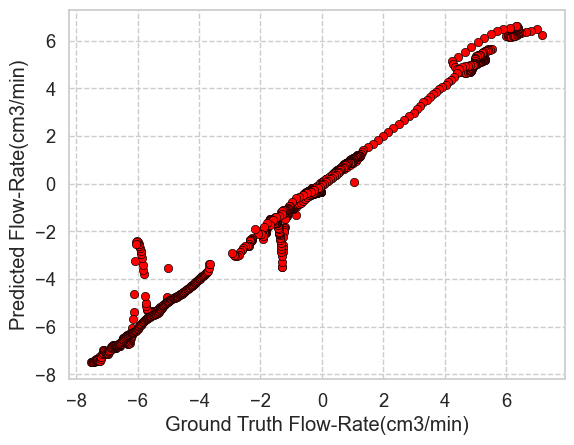

In [57]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=np.squeeze(train_target), y=train_pred, color='red', edgecolor='black')

plt.xlabel('Ground Truth Flow-Rate(cm3/min)')
plt.ylabel('Predicted Flow-Rate(cm3/min)')

In [58]:
abs_error = np.abs(train_pred - np.squeeze(train_target))
rela_error = abs_error/np.abs((np.squeeze(train_target))+0.001)
rela_error*=100

In [59]:
print(np.mean(abs_error), np.mean(rela_error))

0.15225607318323803 20.815377281116604


In [66]:
print(r2_score(np.squeeze(train_target), train_pred))

0.9861033246757547


<Axes: >

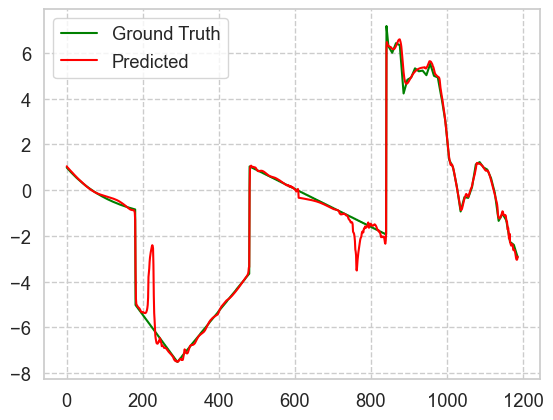

In [64]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(np.squeeze(train_target), color='green', label='Ground Truth')
sns.lineplot(train_pred, color='red', label='Predicted')

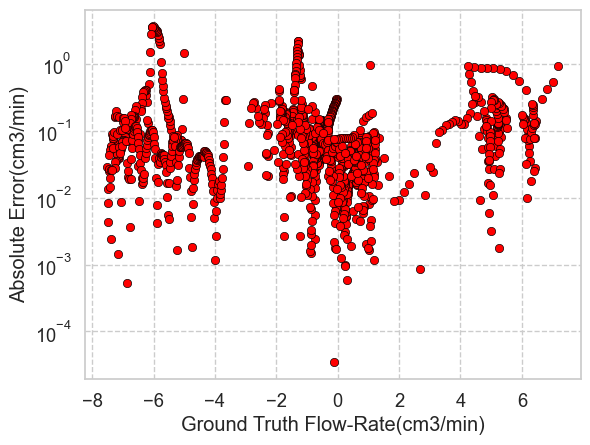

In [60]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=np.squeeze(train_target), y=abs_error, color='red', edgecolor='black')

plt.xlabel('Ground Truth Flow-Rate(cm3/min)')
plt.ylabel('Absolute Error(cm3/min)')
plt.yscale('log')

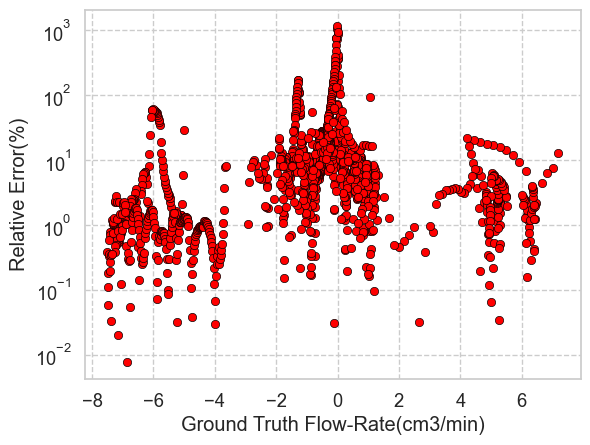

In [61]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=np.squeeze(train_target), y=rela_error, color='red', edgecolor='black')

plt.xlabel('Ground Truth Flow-Rate(cm3/min)')
plt.ylabel('Relative Error(%)')
plt.yscale('log')